In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import util


Aufgaben für nächsten 8 Wochen:
    - Data Cleaning (siehe Mattis` Plot) --- Max und Erik
        - 23/24 Daten cleanen, wo sind da die Daten? //Lösung Max: unterhalb einer Minute fliegt raus
        - 100 m Hürden (F) / 110 m Hürden (M)
        - Schwarze Punkte Marathon 19/20
        - 10 000 m und 5 km auch wahrscheinlich fehlerhaft
        - unterschiedliche Gewichte bei Sportutensilien pro Alter/Geschlecht auf jeden Fall + über Jahre (vor allem Youth Girls!!!)
        - Krasse Outlier raus (Eine Herangehensweise über World Atheltic Score, oder alle Datenpunkte plotten)
        - verschiedenes plotten und einfach common sense
        - (Zehn- & Siebenkampf raus?, ggf auch Gehen)
        - Hier auch für Report etwas plotten/niederzuschreiben, um Herausforderungen klar zu machen
    - Forschungsfragen und Hypothesen --- Mattis und Luca
        - Suche nach größeren Feldern wie:
        - "Leistungsdichte entfernt sich von den Top Leistung" (einsame Spitze in jüngeren Jahren, zB über SD)
        - Beeinflussung Corona der Leistungen (Technische (Speerwurf, Hürden etc.) - vs Nicht technische (Laufen), weniger Wettkampforte während Corona)
        - Durchschnittliche Formkurve
        - (Örtliche Unterschiede: Heimvorteil, wo beste Leistungen / eigentlich wenig interessant aufgrund von untypischer Fan- und Vereinskultur)
        - (Zeitliche Unterschiede: Was ist der Top-Monat? Wie oft Top-Leistungen bei DM)
    - Anreicherung von Daten
        - World Athletic Score zuverlässig und korrekt zuordnen (so, dass es auch gescheit im Report landen kann)
        - Liste aller Weltrekorde (in den jeweiligen Jahren)
        + was einem noch einfällt
    - Analyse
        - siehe Forschungsfragen und Hypothesen
        - Nach ersten Plots und Erkentnissen noch tiefer buddeln & Storyline entwickeln
        - keine Scheu vor höheren statistischen Ideen
        - Achtung: Nur 4 Seiten Text! Daher maximal 2 Forschungfragen, wahrscheinlich eher eine
    - Paper schreiben
        - Plot bestenfalls mit "Tueplot"


Timeline:
    - Montag Vormittag Meeting! Bis dahin einfach erstmal loslegen & genauere Milestones dann besprechen

##### DF Mac

In [ ]:
data_path = "/Users/erik/Library/CloudStorage/OneDrive-Persönlich/Tübingen Studium/1. Semester/Data Literacy/Project/Data_fixed800.csv"
df = pd.read_csv(data_path, sep=';', decimal=',')


##### DF Windows

In [ ]:
df = pd.read_csv('Data.csv', sep=';', decimal=',')

##### util load_data

In [ ]:
df = util.load_data()
df

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg
...,...,...,...,...,...,...,...,...,...,...,...
211554,2023,M,14,Speerwurf,40.64,NaN,Tizian Zoeger,2010,LAC Aschersleben,29.04.2023,Schoenebeck
211555,2023,M,14,Speerwurf,40.48,NaN,Phil Matthias,2009,SV Halle,07.05.2023,Halle (Saale)
211556,2023,M,14,Speerwurf,40.38,NaN,Laurin Steep,2009,MTV Dannenberg,16.09.2023,Fallersleben (Wolfsburg)
211557,2023,M,14,Speerwurf,40.36,NaN,Rico Lange,2009,TSV Chemie Premnitz,02.09.2023,Berlin-Lichterfelde


##### 800m

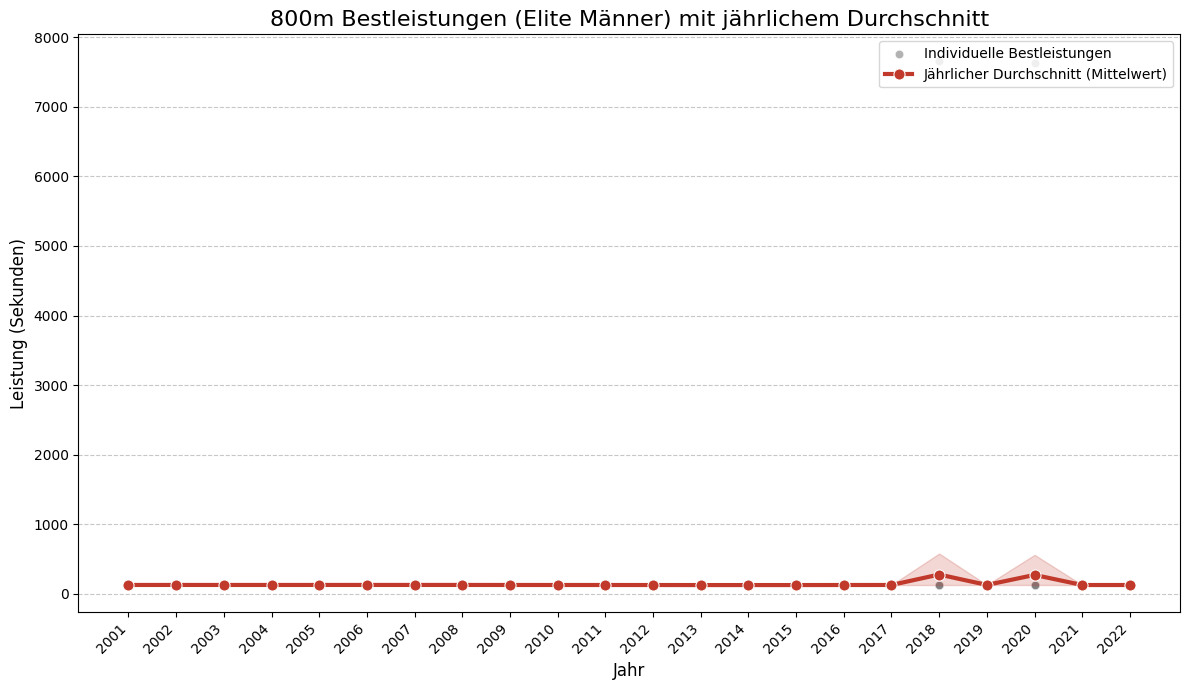

In [ ]:
df_transformiert = df

# 1. Daten filtern (Männer, 800 m, Elite-Klasse)
df_800m_elite = df[
    (df['geschlecht'] == 'W') &
    (df['disziplin'] == '800 m') &
    (df['altersklasse'] == 'Frauen') & # <--- ELITE-FILTER
    (df['leistung'].notna())
].copy()

# 2. Plot erstellen
plt.figure(figsize=(12, 7))

# --- Scatterplot der Einzelzeiten ---
# Jeder Punkt ist eine individuelle Bestleistung
sns.scatterplot(
    data=df_800m_elite,
    x='jahr',
    y='leistung',
    color='gray',
    alpha=0.6,          
    label='Individuelle Bestleistungen'
)

# --- Linien-Plot des Mittelwerts pro Jahr ---
# 'estimator="mean"' sorgt dafür, dass pro Jahr der Mittelwert berechnet wird.
sns.lineplot(
    data=df_800m_elite,
    x='jahr',
    y='leistung',
    estimator='mean',     
    color='#C0392B',      # Ein auffälliges Rot, um den Trend hervorzuheben
    linewidth=3,
    marker='o',
    markersize=8,
    label='Jährlicher Durchschnitt (Mittelwert)'
)

# 3. Titel und Beschriftungen
plt.title('800m Bestleistungen (Elite Männer) mit jährlichem Durchschnitt', fontsize=16)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Leistung (Sekunden)', fontsize=12) 

# Beschränke die x-Achse auf ganze Zahlen (Jahre)
plt.xticks(df_800m_elite['jahr'].unique().astype(int), rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
#plt.ylim(100, 140)
plt.show()

df_transformiert.to_csv("Data_transformiert2.csv", sep=";", index=False, decimal=',')

##### Names 800m sprinter

In [ ]:

# 1. Filtern des Datensatzes nach den drei Kriterien
df_800m_2012 = df[
    (df['disziplin'] == '800 m') & 
    (df['geschlecht'] == 'M') & 
    (df['jahr'] == 2012)
].copy()

# 2. Auswahl der Namensspalte und Entfernen von Duplikaten
# .unique() gibt ein NumPy-Array der eindeutigen Namen zurück.
# Wir wandeln es in eine Liste um, um es lesbarer zu machen.
sprinter_namen = df_800m_2012['name'].unique().tolist()

# 3. Ausgabe der Namen
print(f"Es wurden {len(sprinter_namen)} 800m-Sprinter (Männer) im Jahr 2012 gefunden.")
print("-------------------------------------------------------")
print(sprinter_namen)

Es wurden 184 800m-Sprinter (Männer) im Jahr 2012 gefunden.
-------------------------------------------------------
['Dennis Biederbick', 'Marvin Hebenbrock', 'Lukas Abele', 'Frederik Ruppert', 'Heritier Kambuya', 'Tilmann Garthe', 'Peer Soenksen', 'Robert Blumentritt', 'Lukas Eisele', 'Tobias Henning', 'Robin Roemer', 'Marvin Heinrich', 'Clemens Pigorsch', 'Marvin Thomas', 'Nicolas Deutschbein', 'Timon Schaare', 'Lars Wagner', 'Marcus Ellermann', 'Simon Schophaus', 'Artur Stemwedel', 'Maurice Theisen', 'Florian Drocholl', 'Elias Huetig', 'Stefan Schwartz', 'Jannik Seelhoefer', 'Yves Held', 'Marcel Peters', 'Jan Ruhrmann', 'Joern Kaiser', 'Lukas Gliniorz', 'Timo Stegmueller', 'Arne Achmus', 'Arya Mesgary', 'Hans Kneist', 'Leopold Stefanski', 'Christopher Traichel', 'Eddy Schmidt', 'Konstantin Schulz', 'Finn Merten', 'Felix Karl', 'Niklas Harsy', 'Luca Gehling', 'Jurek Odenbach', 'Markus Stehle', 'Benjamin Mannsdoerfer', 'Julian Weber', 'Felix Tabeling', 'Marcel Langjahr', 'Lukas Birk L

##### Average Time

In [ ]:
# Durchschnitt 100m
df['leistung_num'] = pd.to_numeric(
    df['leistung'].str.replace(',', '.', regex=False),
    errors='coerce'
)
durchschnitt_100m = df[df['disziplin'] == '100 m']['leistung_num'].mean()
print(
    f"{durchschnitt_100m:.2f} Sekunden"
)

# Durchschnitt 200m
df['leistung_num'] = pd.to_numeric(
    df['leistung'].str.replace(',', '.', regex=False),
    errors='coerce'
)
durchschnitt_200m = df[df['disziplin'] == '200 m']['leistung_num'].mean()
print(
    f"{durchschnitt_200m:.2f} Sekunden"
)

##### violin plot

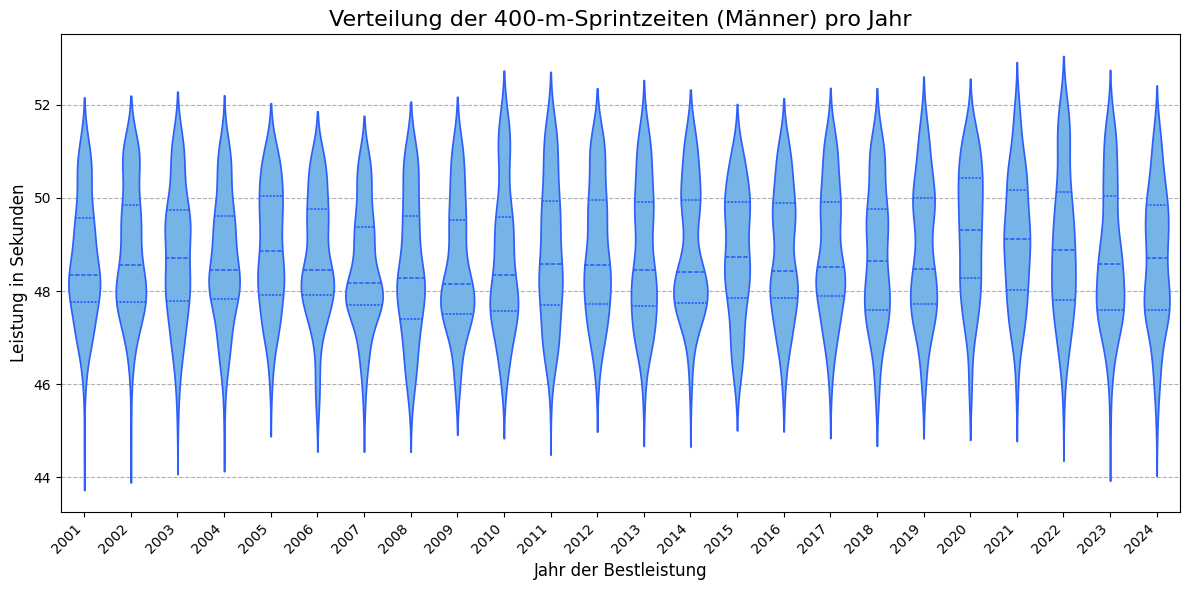

In [ ]:
df_plot = df[
    (df['disziplin'] == '400 m') &
    (df['geschlecht'] == 'M')
].copy()

# Entferne alle Zeilen, bei denen die Leistung NaN ist (falls die Konvertierung fehlschlug)
df_plot.dropna(subset=['leistung'], inplace=True)


# 2. Violin Plot erstellen

# Setzen der Größe des Plots
plt.figure(figsize=(12, 6))

# Erstellung des Violin Plots mit seaborn
# x: Jahr, y: Zeit in Sekunden, data: gefilterter DataFrame
sns.violinplot(
    x='jahr',
    y='leistung',
    data=df_plot,
    inner='quartile',  # Fügt die Quartile (25%, 50%, 75%) als Linien hinzu
    color='#63B6FB',
    edgecolor='#2F5FFA',
    zorder=2
    # palette='viridis'  # Eine Farbskala
)

# 3. Titel und Achsenbeschriftungen hinzufügen
plt.title('Verteilung der 400-m-Sprintzeiten (Männer) pro Jahr', fontsize=16)
plt.xlabel('Jahr der Bestleistung', fontsize=12)
plt.ylabel('Leistung in Sekunden', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Gitternetzlinien hinzufügen
plt.grid(axis='y', linestyle='--', zorder=1)

# Plot anzeigen
plt.tight_layout()  # Passt den Plot an, damit nichts abgeschnitten wird
plt.show()

##### Comparison street and track

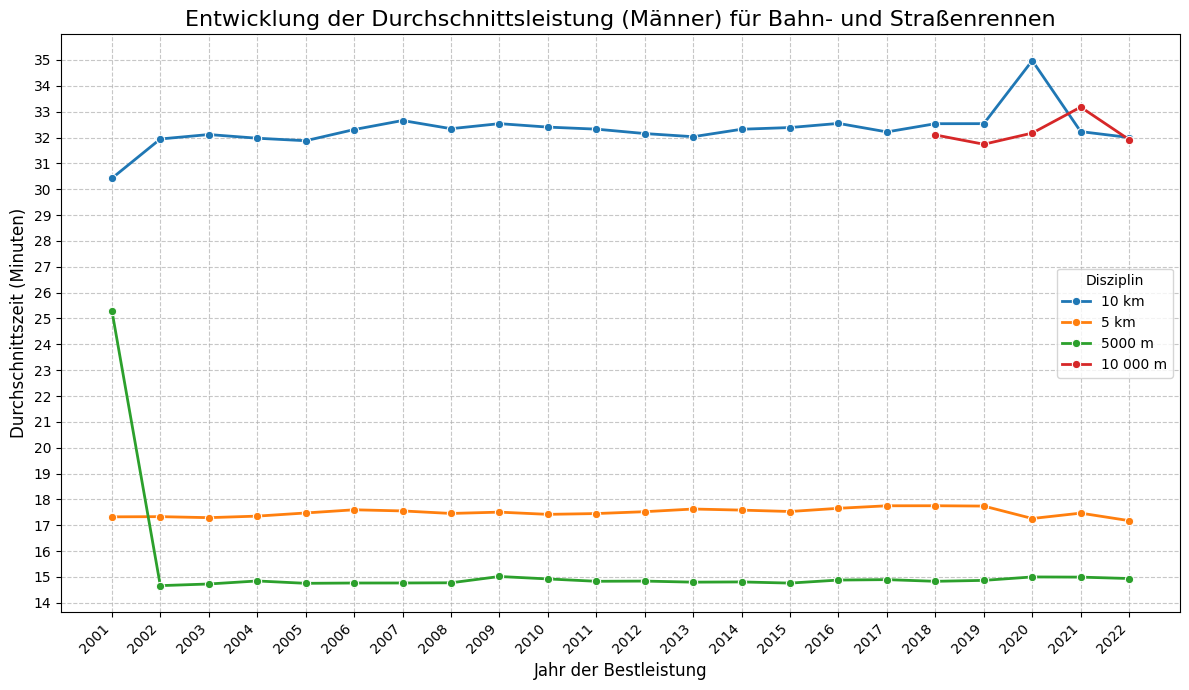

In [ ]:

# 1. Daten filtern (Männer und die Ziel-Distanzen)
target_disciplines = ['5 km', '5000 m', '10 km', '10 000 m']

df_filtered = df[
    (df['geschlecht'] == 'M') &
    (df['disziplin'].isin(target_disciplines)) &
    (df['leistung'].notna())
]

# 2. Aggregation: Mittelwert (Mean) pro Jahr und Disziplin berechnen
df_mean = df_filtered.groupby(['jahr', 'disziplin'])['leistung'].mean().reset_index()

# 3. Umwandlung der Zeit von Sekunden in Minuten (NEU)
df_mean['leistung_min'] = df_mean['leistung'] / 60

# 4. Multi-Linien-Plot erstellen (Seaborn Lineplot)

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=df_mean,
    x='jahr',
    y='leistung_min', # Y-Achse zeigt nun Minuten
    hue='disziplin',
    marker='o',
    linewidth=2
)

# 5. Titel und Beschriftungen
plt.title('Entwicklung der Durchschnittsleistung (Männer) für Bahn- und Straßenrennen', fontsize=16)
plt.xlabel('Jahr der Bestleistung', fontsize=12)
plt.ylabel('Durchschnittszeit (Minuten)', fontsize=12)

# Beschränke die x-Achse auf ganze Zahlen (Jahre)
plt.xticks(df_mean['jahr'].unique().astype(int), rotation=45, ha='right')
plt.yticks(np.arange(np.floor(df_mean['leistung_min'].min()), np.ceil(df_mean['leistung_min'].max()) + 1, 1)) # Y-Achse in ganzen Minuten-Schritten

plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.legend(title='Disziplin')
plt.tight_layout()
plt.show()

##### Outlier finden mit z score

In [ ]:
# 1. Erzwinge numerische Werte
# 'coerce' sorgt dafür, dass alle Fehler (Texte, die übrig blieben) zu NaN werden
df['leistung'] = pd.to_numeric(df['leistung'], errors='coerce')

# 2. (Optional) Lösche Zeilen, die jetzt NaN sind (also die nicht konvertierbar waren)
df = df.dropna(subset=['leistung'])

# JETZT erst die Outlier-Suche starten
bad_data = find_outliers(df, threshold=3)


def find_outliers(df, threshold=3):
    """
    Findet Ausreißer basierend auf Z-Score innerhalb von Gruppen.
    threshold=3 bedeutet: Alles was weiter als 3 Standardabweichungen vom Schnitt weg ist.
    """
    
    # 1. Wir kopieren den DF, um nichts kaputt zu machen
    df_check = df.copy()
    
    # 2. Berechne Mittelwert und Standardabweichung PRO GRUPPE (Disziplin, Geschlecht, AK)
    #    transform() sorgt dafür, dass die berechneten Werte in jeder Zeile stehen
    groups = df_check.groupby(['disziplin', 'geschlecht', 'altersklasse'])['leistung']
    
    df_check['grp_mean'] = groups.transform('mean')
    df_check['grp_std'] = groups.transform('std')
    
    # 3. Berechne den Z-Score: Wie viele Standardabweichungen ist der Wert entfernt?
    #    Formel: (Wert - Durchschnitt) / Standardabweichung
    df_check['z_score'] = (df_check['leistung'] - df_check['grp_mean']) / df_check['grp_std']
    
    # 4. Filtere alles, was extrem ist (z.B. > 3 oder < -3)
    #    Wir füllen NA mit 0, falls eine Gruppe nur 1 Person hat (da ist std = NaN)
    outliers = df_check[df_check['z_score'].abs().fillna(0) > threshold].copy()
    
    # Sortieren nach der stärke der Abweichung
    outliers = outliers.sort_values(by='z_score', key=abs, ascending=False)
    
    return outliers[['name', 'jahr', 'disziplin', 'altersklasse', 'leistung', 'grp_mean', 'z_score']]

# --- ANWENDUNG ---

# Finde die Ausreißer
bad_data = find_outliers(df_transformiert, threshold=5) # 3.5 ist sehr streng, 3 ist normal

print(f"Gefundene potenzielle Fehler: {len(bad_data)}")
print("-" * 30)

# Zeige die Top 10 verrücktesten Werte
print(bad_data.head(10))

# Speichert die Fehlerliste als CSV (Excel-kompatibel)
bad_data.to_csv("Outliers_Check_z5.csv", sep=";", decimal=",", index=False)

print("Datei 'Outliers_Check.csv' wurde erstellt. Bitte in Excel öffnen.")

Gefundene potenzielle Fehler: 108
------------------------------
                       name  jahr         disziplin altersklasse  leistung  \
187141       Dennis Messmer  2018  3000 m Hindernis      Maenner  34037.00   
173068        Olivia Guerth  2019            3000 m           18  36982.00   
167426         Lena Posniak  2018             800 m          U23   7664.00   
168150         Lena Posniak  2018             800 m       Frauen   7664.00   
147308     Ann-Kathrin Kopf  2020             800 m       Frauen   7628.00   
183230           Alina Herr  2020             800 m           18     77.60   
186893    Andreas Strassner  2018      Halbmarathon      Maenner     66.26   
186896  Dominik Fabianowski  2018      Halbmarathon      Maenner     66.31   
70648          Thomas Bruns  2006      Halbmarathon      Maenner     67.36   
177080      Steven Orlowski  2018      Halbmarathon          U23     68.55   

           grp_mean    z_score  
187141   590.839953  32.604706  
173068   7

#### plot um outlier darzustellen

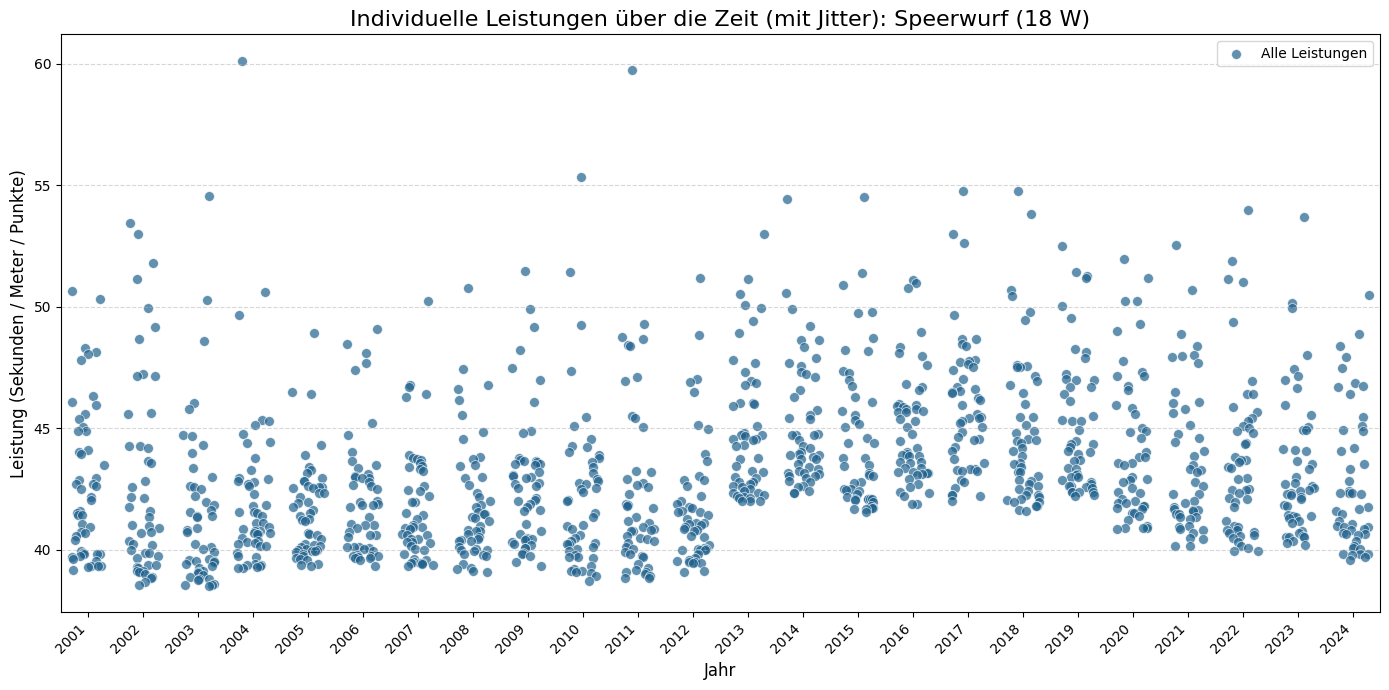

In [ ]:

# --- 1. DEINE FILTER VORAB DEFINIEREN ---
SELECTED_DISCIPLINE = 'Speerwurf'
SELECTED_GENDER = 'W'      # 'W' für Frauen, 'M' für Männer
SELECTED_AGE_CLASS = '18' # Elite-Klasse. Wähle z.B. 'U18' für eine Jugendklasse.
# ----------------------------------------

# 2. DATEN FILTERN
df_plot = df_transformiert[
    (df_transformiert['geschlecht'] == SELECTED_GENDER) &
    (df_transformiert['disziplin'] == SELECTED_DISCIPLINE) &
    (df_transformiert['altersklasse'] == SELECTED_AGE_CLASS) &
    (df_transformiert['leistung'].notna())
].copy()

# --- NEU: JITTERING HINZUFÜGEN ---
# Erstelle eine Kopie der 'jahr'-Spalte für das Jittering, um die Originaldaten nicht zu ändern
df_plot['jahr_jittered'] = df_plot['jahr'] + np.random.uniform(-0.3, 0.3, len(df_plot))
# -0.3 bis 0.3 bedeutet, dass die Punkte um max. 30% des Jahres nach links/rechts verschoben werden.
# Das ist ein guter Wert, damit sie sich nicht zu sehr überlappen, aber noch klar zum Jahr gehören.
# ---------------------------------

# 3. PLOT ERSTELLEN (Scatterplot für alle Punkte)
plt.figure(figsize=(14, 7))

sns.scatterplot(
    data=df_plot,
    x='jahr_jittered', # HIER WIRD DIE GEJITTERTE SPALTE VERWENDET
    y='leistung',
    color='#1F618D',         # Dunkles Blau für die Punkte
    alpha=0.7,               # Transparenz, damit man Überlappungen sieht
    s=50,                    # Punktgröße
    label='Alle Leistungen'
)

# 4. TITEL UND BESCHRIFTUNGEN
plt.title(
    f'Individuelle Leistungen über die Zeit (mit Jitter): {SELECTED_DISCIPLINE} ({SELECTED_AGE_CLASS} {SELECTED_GENDER})', 
    fontsize=16
)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Leistung (Sekunden / Meter / Punkte)', fontsize=12) 

# Optionale Y-Achsen Beschränkung (wie gewünscht, z.B. für 800m)
# plt.ylim(top=140) 

# Achsenformatierung (X-Achse)
# Die x-Ticks bleiben auf den Originaljahren, da das Jittering nur visuell ist.
plt.xticks(df_plot['jahr'].unique().astype(int), rotation=45, ha='right')
plt.xlim(df_plot['jahr'].min() - 0.5, df_plot['jahr'].max() + 0.5) # Sorgt dafür, dass die gejitterten Punkte nicht abgeschnitten werden

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()